# Real Estate Price Prediction for Houses in New Taipei City - Mattia Carella

## Imports, data loading, and constants

In [ ]:
!pip install ucimlrepo contextily

In [2]:
import contextily as cx
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown
from scikeras.wrappers import KerasRegressor
from sklearn import linear_model
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.metrics import (
    get_scorer_names,
)
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from ucimlrepo import fetch_ucirepo
from utils import get_kfold_results, kfold_model, show_correlation_matrix

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

RANDOM_STATE = 42
DROP_OUTLIERS = True  # drops houses whose price falls outside Tukey's fence
DROP_YONGHE = True  # drops 3 houses that are not part of the Xindian district
DROP_TRANSACTION_DATE = True


keras.utils.set_random_seed(RANDOM_STATE)
tf.config.list_physical_devices("GPU")

[]

## Gathering information about the domain and the task

`real_estate_valuation` comes with a nested `metadata` dictionary containing plenty of useful information about the task. Let's explore it further!

In [3]:
metadata = real_estate_valuation.metadata

Markdown(f"""# {metadata.name}
{metadata.abstract}
- Type of regression: {metadata.characteristics[0]}
- Number of observations: {metadata.num_instances}
- Number of features: {metadata.num_features}
- Feature_types: {metadata.feature_types}
- Target: {metadata.target_col}
- Missing values? {metadata.has_missing_values}

## Features description

{"- X".join(metadata.additional_info.variable_info.split("X"))}

""")

# qua si parlava di uno split 2/3 1/3, riferendosi però a quello adottato dall'autore del paper
## Train/test split

# {metadata.additional_info.summary}

# Real Estate Valuation
The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. 
- Type of regression: Multivariate
- Number of observations: 414
- Number of features: 6
- Feature_types: ['Integer', 'Real']
- Target: ['Y house price of unit area']
- Missing values? no

## Features description

The inputs are as follows
- X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.)
- X2=the house age (unit: year)
- X3=the distance to the nearest MRT station (unit: meter)
- X4=the number of convenience stores in the living circle on foot (integer)
- X5=the geographic coordinate, latitude. (unit: degree)
- X6=the geographic coordinate, longitude. (unit: degree)

The output is as follow
Y= house price of unit area (10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)




---

## Exploratory Analysis

Now that we have gathered enough information about the problem, we can start exploring the data before trying to fit a model to it.

In [4]:
X: pd.DataFrame = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

X_y = pd.concat([X, y], axis=1)
X_y

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


### Conditionally dropping the outlier

There is a large outlier in the target variable that we might want to drop (dropping it increases $R^2_\text{test}$ by ~$0.02$):

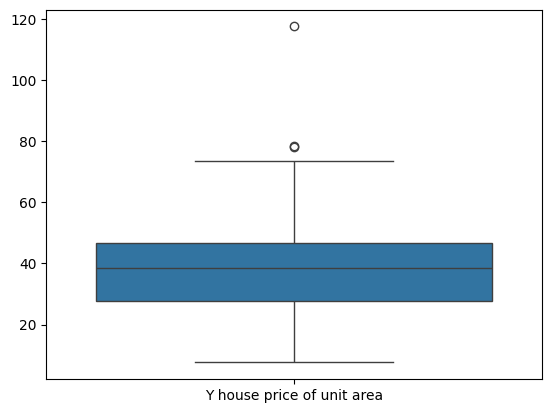

In [5]:
sns.boxplot(y)
plt.show()

if DROP_OUTLIERS:
    idx = y["Y house price of unit area"].sort_values().index[-3:]
    # idx = y["Y house price of unit area"].idxmax()
    X, y = X.drop(index=idx), y.drop(index=idx)
    X_y = pd.concat([X, y], axis=1)

## Plotting houses on a map of the Xindian district

There are 3 properties that are not actually part of the Xindian district; they belong to the Yonghe District instead, as you can see on [Google Maps](https://www.google.it/maps/place/Xindian+District,+New+Taipei+City,+Taiwan+231/@24.949734,121.5059999,13z/data=!4m6!3m5!1s0x346803de337f4fe1:0xe29baf27fbf0968f!8m2!3d24.978282!4d121.5394822!16zL20vMDNzcmN0?entry=ttu&g_ep=EgoyMDI2MDYxNi4wIKXMDSoASAFQAw%3D%3D).

We'll proceed by removing them (easy to do, since they are the 3 with the largest latitude).

This choice gained us an additional percentage point of $R^2$ across all models.

In [6]:
if DROP_YONGHE:
    idx = X["X5 latitude"].sort_values().index[-3:]
    X, y = X.drop(index=idx), y.drop(index=idx)
    X_y = pd.concat([X, y], axis=1)

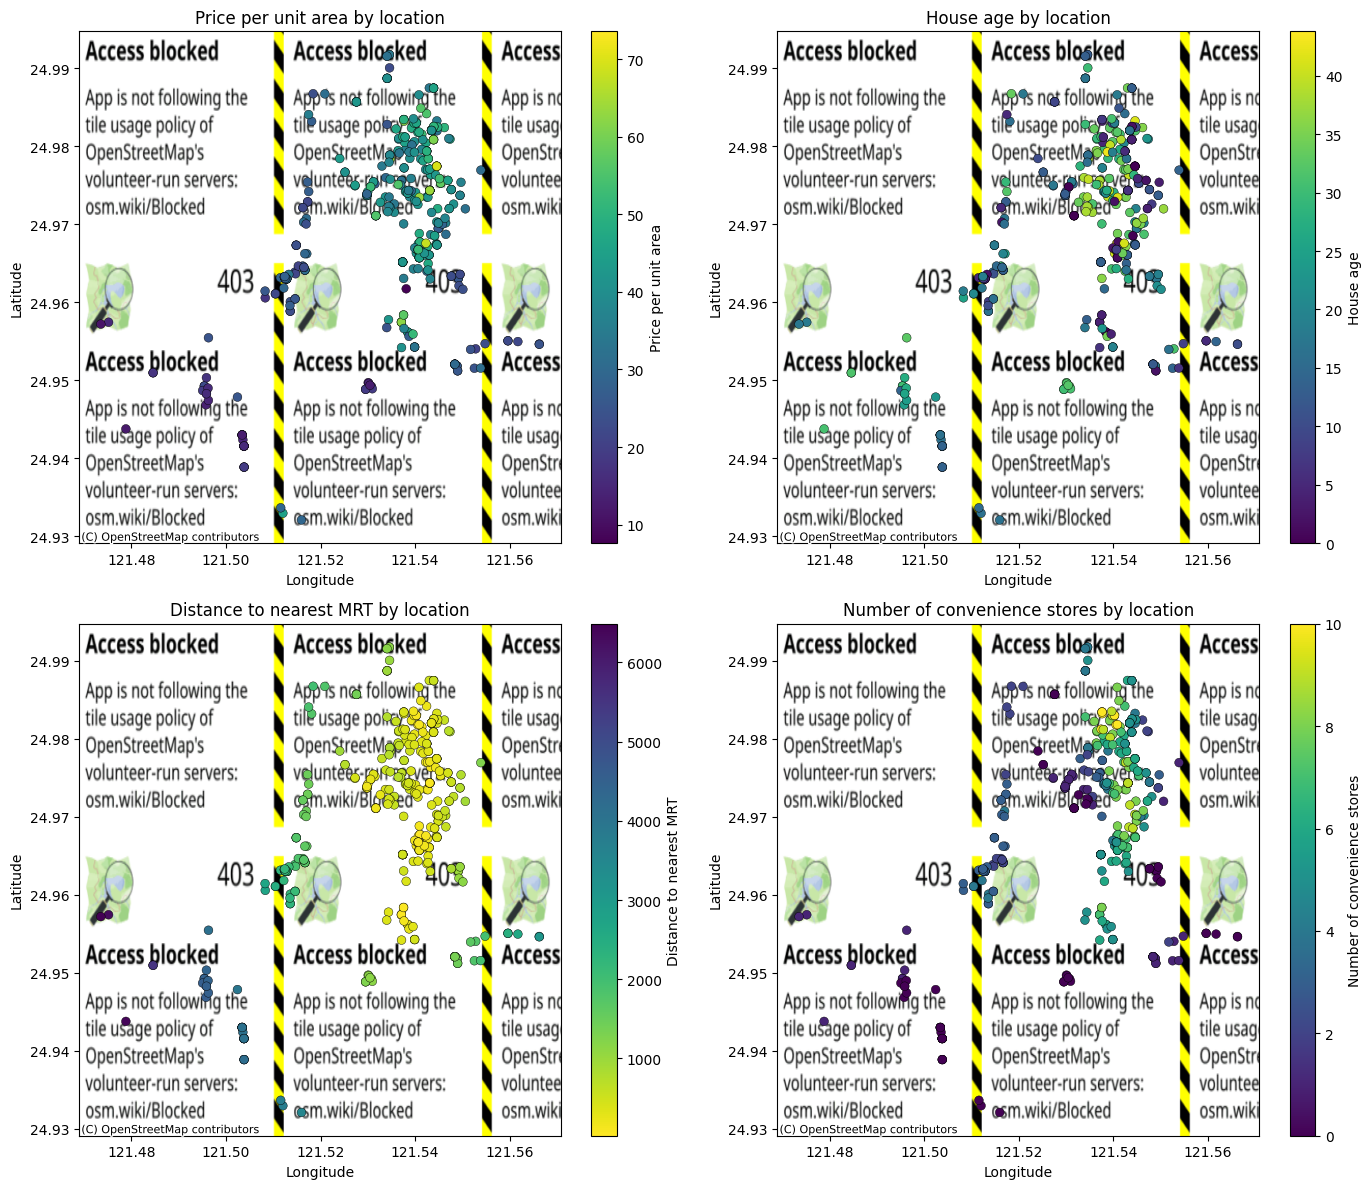

In [ ]:
colorings = {
    "Price per unit area": X_y["Y house price of unit area"],
    "House age": X["X2 house age"],
    "Distance to nearest MRT": X["X3 distance to the nearest MRT station"],
    "Number of convenience stores": X["X4 number of convenience stores"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (label, values) in zip(axes.flat, colorings.items()):
    # reverse colormap for MRT distance to improve readability
    cmap = "viridis_r" if label == "Distance to nearest MRT" else "viridis"
    sc = ax.scatter(
        X["X6 longitude"],
        X["X5 latitude"],
        c=values,
        cmap=cmap,
        s=40,
        edgecolor="black",
        linewidth=0.3,
        zorder=2,
    )

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik)
    fig.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{label} by location")

plt.tight_layout()
plt.show()

### Feature distributions

- House age: ranges from 0 to 43 years.
- Transaction date: peaks during Q2 of 2013.

### Correlation study: pairplot and correlation matrix

From the correlation matrix we immediately discover that:

- Longitude forms a "swoosh"-like curve against the distance to MRT. This is because all of the MRT stations are located in the urban, north-eastern part of the district, at around 121.54 in longitude.
- As the distance to MRT increases -> the number of convenience stores decreases -> longitude and latitude decrease -> houses get cheaper.
- Not all properties near an MRT station are expensive, but if a property is expensive, then it is most likely located near an MRT.

### Dropping the transaction date

$y$ exhibits no correlation with the transaction date, suggesting that the real estate market did not undergo any particular changes during the sampled period. This makes sense, since the dataset spans only about a year between the oldest and newest samples, whereas price cycles usually take longer to unfold and therefore to become noticeable.

For this reason, I decided to remove it entirely from the design matrix and, as we are going to see, this has little to no effect on performance.


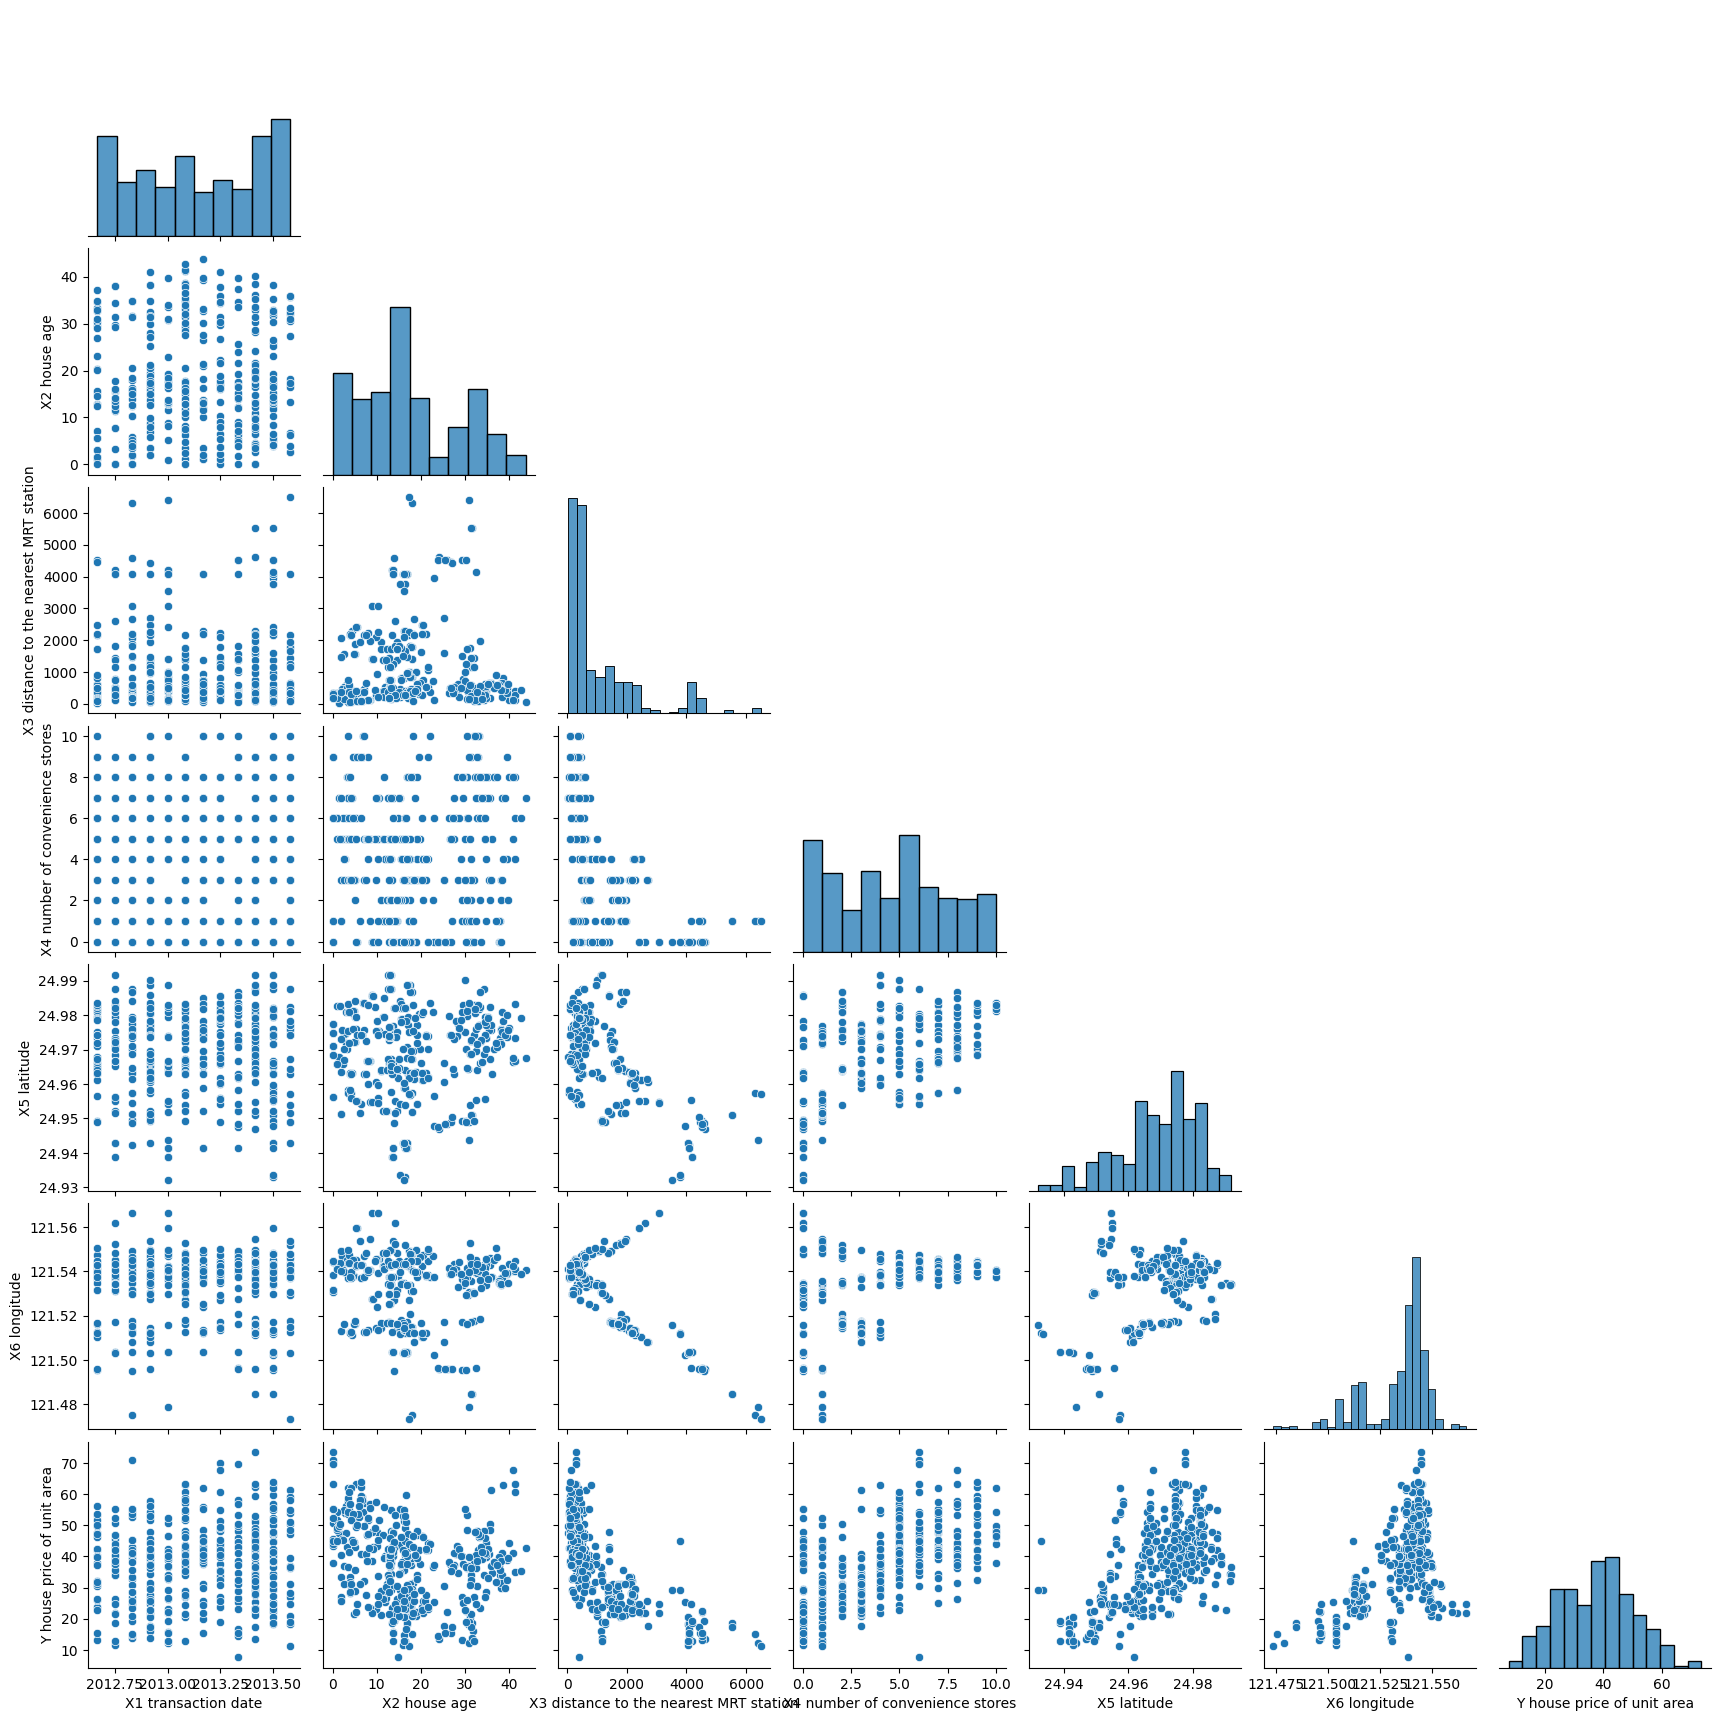

In [8]:
sns.pairplot(X_y, corner=True)
plt.show()

From what we have seen, latitude, longitude, the number of convenience stores, and the distance to MRT all show relevant correlation and, as a consequence, redundancy.

Performing PCA on this dataset will yield a first principal component that summarizes how peripheral a property is.

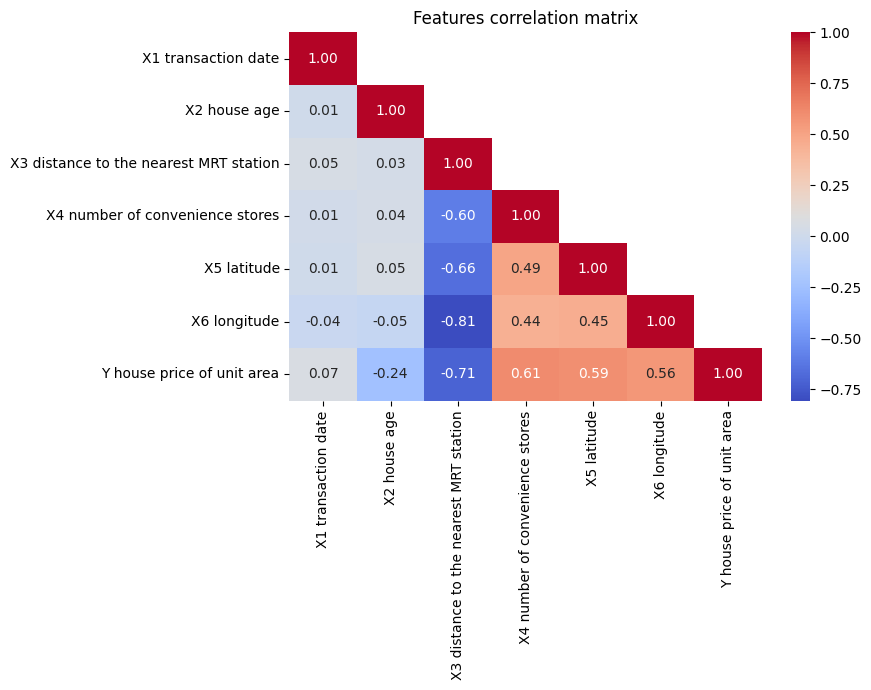

In [9]:
corr = X_y.corr()

plt.figure(figsize=(9, 7))

show_correlation_matrix(corr, "Features correlation matrix")

In [10]:
if DROP_TRANSACTION_DATE:
    X = X.drop(columns=["X1 transaction date"])

---

## Task

Given $X_1, \dots, X_6$, predict the price per Ping (a unit of area) of the houses.

We do so by first training different regression models with `model.fit`, which internally uses the OLS method.
Then, instead of limiting ourselves to a single train/test split, we run a repeated 5-fold cross-validation in order to get a more precise estimate of the generalization error.

All of the fitting, cross-validating, and metric computation is done by `cross_validate`, a handy API that spares us the hassle of manually handling the for-loop we would need when using `KFold`.


### Feature scaling


Since I used some scale-sensitive models (like PCA, which relies on variance), I decided to add a scaling step to all models for consistency. Doing so does not alter the results of the models that don't need it, and if anything, it makes them more easily interpretable, since the learned coefficients share the same scale.


In fact, initially I did not scale the linear regression, so it ended up with a huge weight on latitude (~200), since latitude varies by only a few decimal points, while the other $w_i$ ranged between $\pm 5$, making them uninterpretable.

In [11]:
# Scikit-learn follows "higher is better" convention, that's why the metrics below are multplied by -1
# I wanted to mse's name
list(filter(lambda s: "square" in s, get_scorer_names()))

['neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error']

### Regression models

After trying and tweaking different models, this is what I came up with:

- **Standard Linear Regression**: acts as a baseline and exhibits mediocre performance (R-squared ~0.62), since the relationships between features aren't quite linear.
- **Degree-2 Polynomial Regression**: as expected, it outperforms the baseline model by over 0.1 in R-squared. This is because a 2nd-degree polynomial allows a better fit to the nonlinear relationships.
- **PC Regression**: achieves the smallest gap between test and train R-squared, but it underperforms the baseline model. Again, this is expected, since I'm capping the maximum amount of variance it can explain by keeping only the first 4 PCs.
- **Degree-3 PCR**: after a lot of tweaking, this model manages to outperform Degree-2 Polynomial Regression by a tiny bit, thanks to the regularizing effect of PCA, which let me step on the gas with 3rd-degree `PolynomialFeatures`.
- **KNN Regression**: doesn't even require training, yet still manages to beat all of the above.


> As a side note, the difference in performance between some of the models is fairly small and could be due to a lucky `RANDOM_STATE`.

In [8]:
second_deg_reg = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2),
    linear_model.LinearRegression(),
)
third_deg_pcr = make_pipeline(
    StandardScaler(),
    PCA(n_components=4, random_state=RANDOM_STATE),
    PolynomialFeatures(degree=3),
    linear_model.LinearRegression(),
)

regression_models = {
    "Linear Regression": make_pipeline(
        StandardScaler(),
        linear_model.LinearRegression(),
    ),
    # higher k reduces overfitting
    "KNN Regression": make_pipeline(
        StandardScaler(),
        KNeighborsRegressor(n_neighbors=5, weights="distance"),
    ),
    "Degree-2 Regression": second_deg_reg,
    "Degree-3 PCR": third_deg_pcr,
    "PCR": make_pipeline(
        StandardScaler(),
        PCA(n_components=4, random_state=RANDOM_STATE),
        linear_model.LinearRegression(),
    ),
}

### Cross-validation setup and regression results



In [12]:
rkf = RepeatedKFold(n_repeats=5, random_state=RANDOM_STATE)


scores: dict[str, pd.DataFrame] = {
    name: pd.DataFrame(kfold_model(model, X, y, cv=rkf))
    for (name, model) in regression_models.items()
}

get_kfold_results(scores, show_train=True)

,R-squared test,R-squared train,RMSE test,RMSE train,MAE test,MAE train
Degree-2 Regression,0.724,0.787,-6.623,-5.892,-4.928,-4.403
KNN Regression,0.720,0.997,-6.685,-0.702,-4.869,-0.153
Degree-3 PCR,0.696,0.778,-6.969,-6.021,-5.198,-4.537
Linear Regression,0.633,0.648,-7.677,-7.580,-5.817,-5.723
PCR,0.627,0.640,-7.738,-7.664,-5.909,-5.832


### Parameter inspection

From a quick inspection of the baseline model's parameters, we notice that the most important features are the distance to MRT and the number of convenience stores, followed by house age, latitude, and, lastly, longitude.

In [14]:
# calculate the mean parameters across folds.
pd.DataFrame(
    np.mean(
        [
            np.concatenate([[pipeline[1].intercept_], pipeline[1].coef_])
            for pipeline in scores["Linear Regression"]["estimator"]
        ],
        axis=0,
    ).round(2),
    index=["intercept", *X.columns],
    columns=["model avg"],
).sort_values(by="model avg")

,model avg
X3 distance to the nearest MRT station,-4.97
X2 house age,-3.24
X6 longitude,0.21
X5 latitude,2.59
X4 number of convenience stores,3.60
intercept,37.59


## Deep learning with feed-forward neural networks

Objective: beat KNN Regression's R-squared (~0.758).

I build the network with `keras.Sequential` and wrap it in `scikeras.KerasRegressor` to make it work with `scikit` pipelines.
The `StandardScaler` step matters even more here than for the linear models, since unscaled inputs would result in a gradient dominated by the variables with the largest scale.

### Picking the activation function

At first I tried using sigmoids as activation functions, but the error just wouldn't come down. Moving to ReLU is what really unstuck training, so I kept ReLU from there on.

### Layer structure

Parameter count per `Dense` layer: $S^l \cdot S^{l-1} + \overbrace{S^{l}}^{\mathclap{\text{one bias per unit}}}$

In our case: $\overbrace{(5 \cdot 6 + 6)}^{|\boldsymbol{W}^1| + |\boldsymbol{b}^1|} + \overbrace{(6 \cdot 4 + 4)}^{\dots} + (4 \cdot 1 + 1) = 69$ 

In [14]:
def get_ffnn():
    model = keras.Sequential(
        [
            keras.Input(shape=(len(X.columns),)),
            keras.layers.Dense(6, activation="relu", name="first_hidden_layer"),
            keras.layers.Dense(4, activation="relu", name="second_hidden_layer"),
            keras.layers.Dense(1, name="ouput"),
        ],
        name="FFNN",
    )

    # lr 0.01 instead of the default 0.001, to converge faster
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

    return model


early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
)

ffnn = KerasRegressor(
    get_ffnn,
    random_state=RANDOM_STATE,
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
    validation_split=0.2,
)
ffnn_pipeline = make_pipeline(
    StandardScaler(),
    ffnn,
)
get_ffnn().summary()

Model: "FFNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ first_hidden_layer (Dense)      │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ second_hidden_layer (Dense)     │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ouput (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
ffnn_kfold_result = pd.DataFrame(kfold_model(ffnn_pipeline, X, y)).round(3)
scores["FFNN"] = ffnn_kfold_result

E0000 00:00:1789914156.474233 11416472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1789914162.899093 11416472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

KeyboardInterrupt: 

### Architecture search

Test R-squared for the configurations I tried (numbers are units per hidden layer):

- single layer: 0.705 (12), 0.712 (10)
- two layers: 0.716 (6, 4)
- three layers: 0.716 (6, 4, 2)

In [ ]:
get_kfold_results(scores)

,R-squared test,RMSE test,MAE test
Degree-2 Regression,0.724,-6.623,-4.928
KNN Regression,0.720,-6.685,-4.869
Degree-3 PCR,0.696,-6.969,-5.198
Linear Regression,0.633,-7.677,-5.817
PCR,0.627,-7.738,-5.909


## Ensemble methods

I obtained further improvements by combining weak regressors into a strong one using gradient boosting, and then, with a simple voting committee, I was able to make the final jump to a surprising R-squared value of 0.78.

The FFNN couldn't beat KNN, so I combine the strongest models instead: a boosting approach (GBR on degree-2 features) and a plain averaging committee.

In [11]:
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)

ensemble_models = {
    "Polynomial GBR": make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2),
        gbr,
    ),
    "Voting": VotingRegressor(
        estimators=[
            ("GBR", gbr),
            # ("Polynomial Regression", second_deg_reg),
            ("Degree-3 PCR", third_deg_pcr),
            ("Knn", KNeighborsRegressor()),
        ]
    ),
}

for name, model in ensemble_models.items():
    scores[name] = pd.DataFrame(kfold_model(model, X, y))

final_scores = get_kfold_results(scores, show_train=True)
final_scores

,R-squared test,R-squared train,RMSE test,RMSE train,MAE test,MAE train
Polynomial GBR,0.784,0.958,-5.882,-2.608,-4.255,-2.029
Voting,0.784,0.884,-5.860,-4.344,-4.282,-3.261
Degree-2 Regression,0.724,0.787,-6.623,-5.892,-4.928,-4.403
KNN Regression,0.720,0.997,-6.685,-0.702,-4.869,-0.153
Degree-3 PCR,0.696,0.778,-6.969,-6.021,-5.198,-4.537
Linear Regression,0.633,0.648,-7.677,-7.580,-5.817,-5.723
PCR,0.627,0.640,-7.738,-7.664,-5.909,-5.832


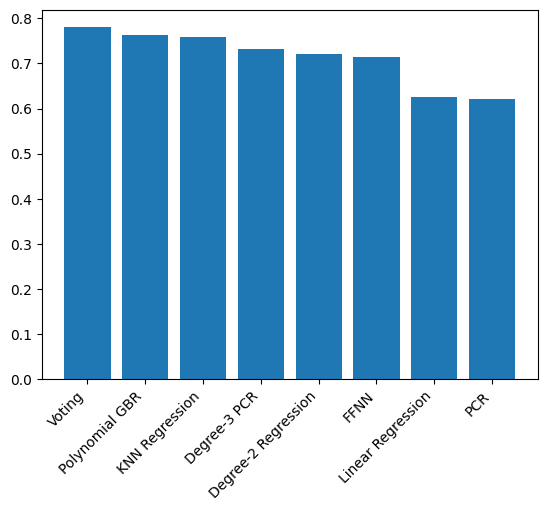

In [28]:
plt.bar(final_scores.index, final_scores["R-squared test"])
plt.xticks(rotation=45, ha="right")
plt.show()

## Conclusions and key insights

- The geographic features turned out to be the strongest predictors of price, while non-linear models clearly outperformed the plain linear baseline, confirming that the price relationships are not linear.
- A note on the transaction date: adding it improves some models but worsens others. In particular, it improves GBR, raising its R-squared to ~0.78 and, as a consequence, lifting the committee to ~0.789. I chose to highlight the pipeline that drops `transaction_date`, since it showcases a more interesting result: the gap of almost two percentage points between "Voting" and "Polynomial GBR".
- Choices made early in the pipeline have more "leverage" than those applied at the end of it, which only squeeze out a final bit of performance once there is little juice left.
- The best result overall came from the voting committee (R-squared ~0.78), which combined partially uncorrelated models; the Appendix explains why averaging their predictions yields an improvement over the individual members.

---

# Appendix

## Why do we get a ~0.016 increase in R-squared from simple model averaging?

Suppose that we have $k$ different models, each one of them making an error $\epsilon_{i}$ on a given example, with $\epsilon_{i}$ drawn from a zero-mean multivariate normal distribution with variances $\mathbb{E}[\epsilon^{2}_{i}]=v$ and covariances $\mathbb{E}[e_{i}e_{j}]=c$, then the error made by the **average prediction** of the ensemble model is

$$
	\frac{1}{k}\sum_{i}\epsilon_{i}
$$

And the expected MSE equals

$$
\begin{align}
	\mathbb{E}\left[	\left( \frac{1}{k}\sum_{i}\epsilon_{i} \right)^{2}\right] &= \frac{1}{k^{2}}\mathbb{E}\left[ \sum_{i} \left( \epsilon_{i}^{2} + \sum_{j \ne i} \epsilon_{i}\epsilon_{j} \right) \right] = \\
	&= \frac{1}{k^{2}}\sum_{i}  \left( v + (k-1) c \right)  = \\
	 &= \frac{1}{k}v + \frac{k-1}{k}c.
\end{align}
$$

This means that if $v=c \Rightarrow$ MSE reduces to $v \Rightarrow$ 0 performance gain;
But if $c=0 \Rightarrow$ errors are perfectly uncorrelated $\Rightarrow$ MSE reduces to $\frac{1}{k}v$!


This is practically impossible in real-world datasets, but this doesn't mean we can't still exploit partially independent errors!

As you can see from the correlation matrix below, error correlation between the models is high but it is not perfect, and this is enough for our voting ensemble to make an improvement compared to the base performance of the members of the committee.

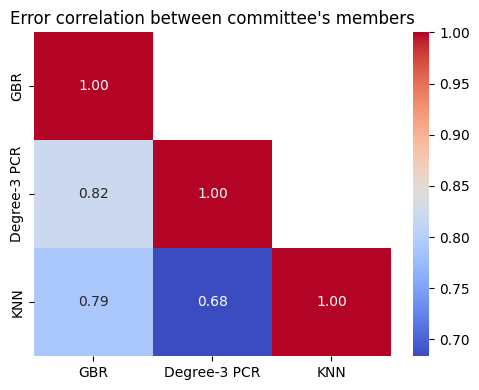

In [ ]:
voters = {
    "GBR": gbr,
    "Degree-3 PCR": third_deg_pcr,
    "KNN": KNeighborsRegressor(),
}

y_true = y.values.ravel()
residuals = pd.DataFrame(
    {
        name: y_true - cross_val_predict(model, X, y_true, cv=5)
        for name, model in voters.items()
    }
)

plt.figure(figsize=(5, 4))
show_correlation_matrix(
    residuals.corr(), "Error correlation between committee's members"
)